# AML Football Evaluation Notebook (Laliga)

#### This notebook contains evaluation results of Laliga model goals prediction. The aim is to understand what the machine learning model focuses on to make prediction and evaluate it accuracy in doing so.

#### We made sure the same hyperparameters that was used in this evaluation results were used in the production model.

#### evaluation was carried out on the last ten percent of total matches played by each team on the dataset.

#### Training and model achitecture technique on the model will remain private.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
laliga_path = os.getenv(r"LALIGA")

laliga = pd.read_parquet(laliga_path)

In [5]:
laliga.head()

,Date,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,Pred_HomeGoals,Pred_AwayGoals,Home_Pred,Away_Pred,Home_Error,Away_Error
0,2026-01-30,Alaves,Espanol,0,2,1,1.004652,1.850989,1,2,1,-1
1,2026-02-08,Alaves,Getafe,1,0,2,1.176402,0.780785,1,1,-1,1
2,2026-02-14,Alaves,Sevilla,0,1,1,0.872135,1.352436,1,1,0,0
3,2026-02-23,Alaves,Girona,1,2,2,1.261289,1.453651,1,1,1,1
4,2026-02-27,Alaves,Levante,0,0,2,1.656969,1.484947,2,1,-2,1


In [6]:
valid = laliga.dropna(subset=["Pred_HomeGoals", "Pred_AwayGoals"])

# Compute MAE
home_mae = mean_absolute_error(valid["GoalsFor"], valid["Pred_HomeGoals"])
away_mae = mean_absolute_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"])

# Compute RMSE
home_rmse = np.sqrt(mean_squared_error(valid["GoalsFor"], valid["Pred_HomeGoals"]))
away_rmse = np.sqrt(mean_squared_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"]))

# Print neatly
print("Model Evaluation Metrics (per match):")
print("-------------------------------------")
print(f"Home Goals -> MAE: {home_mae:.2f}, RMSE: {home_rmse:.2f}")
print(f"Away Goals -> MAE: {away_mae:.2f}, RMSE: {away_rmse:.2f}")
print("\nNotes:")
print("- MAE shows the typical error per match (average goals off).")
print("- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.")

Model Evaluation Metrics (per match):
-------------------------------------
Home Goals -> MAE: 0.90, RMSE: 1.14
Away Goals -> MAE: 0.93, RMSE: 1.21

Notes:
- MAE shows the typical error per match (average goals off).
- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.


In [7]:
laliga.rename(columns={"Pred_HomeGoals": "RawPred_Home"}, inplace=True)
laliga.rename(columns={"Pred_AwayGoals": "RawPred_Away"}, inplace=True)

In [8]:
laliga["Pred_home"] = laliga["RawPred_Home"].round().astype(int)
laliga["Pred_away"] = laliga["RawPred_Away"].round().astype(int)

In [9]:
laliga["Actual_Outcome"] = np.where(laliga["GoalsFor"] > laliga["GoalsAgainst"], "W",
                                    np.where(laliga["GoalsFor"] < laliga["GoalsAgainst"], "L", "D"))

laliga["Predicted_Outcome"] = np.where(laliga["Pred_home"] > laliga["Pred_away"], "W",
                                    np.where(laliga["Pred_home"] < laliga["Pred_away"], "L", "D"))

In [10]:
accuracy = accuracy_score(laliga["Actual_Outcome"], laliga["Predicted_Outcome"])
accuracy

0.4392857142857143

In [11]:
clss_report = classification_report(laliga["Actual_Outcome"].values, laliga["Predicted_Outcome"].values)
print(clss_report)

              precision    recall  f1-score   support

           D       0.27      0.45      0.34        64
           L       0.55      0.53      0.54       111
           W       0.56      0.33      0.42       105

    accuracy                           0.44       280
   macro avg       0.46      0.44      0.43       280
weighted avg       0.49      0.44      0.45       280



In [12]:
laliga["Home_Error"] = laliga["GoalsFor"] - laliga["Pred_home"]
laliga["Away_Error"] = laliga["GoalsAgainst"] - laliga["Pred_away"]

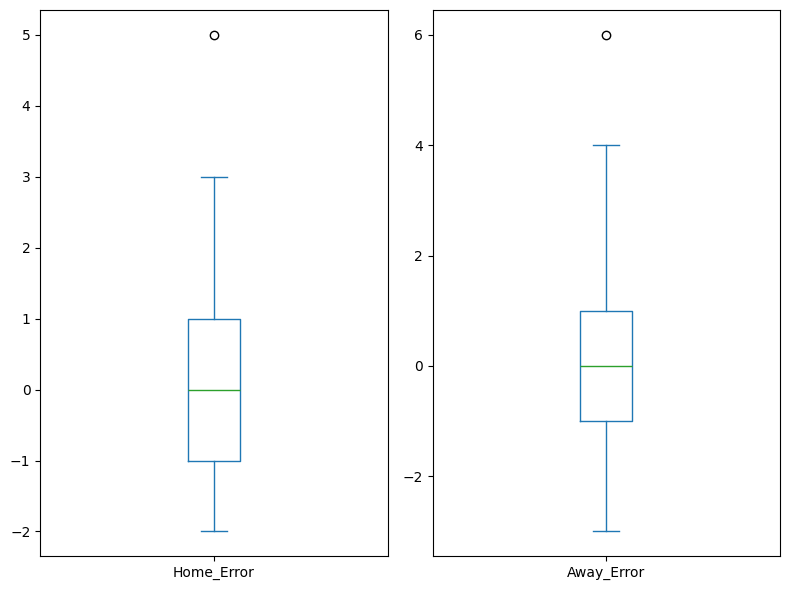

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

laliga["Home_Error"].plot.box(vert=True, ax=axes[0])
laliga["Away_Error"].plot.box(vert=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [14]:
laliga["Home_Error"].value_counts()

Home_Error
 0    95
-1    70
 1    68
 2    29
-2    12
 3     5
 5     1
Name: count, dtype: int64

In [15]:
laliga["Away_Error"].value_counts()

Away_Error
 0    95
-1    77
 1    50
 2    27
-2    21
 3     5
-3     3
 6     1
 4     1
Name: count, dtype: int64

In [16]:
count = laliga["Home_Error"].isin([0, 1, -1]).sum()
print(count/len(laliga))

0.8321428571428572


In [17]:
count = laliga["Away_Error"].isin([0, 1, -1]).sum()
print(count/len(laliga))

0.7928571428571428


In [18]:
laliga["Team"].value_counts()

Team
Ath Bilbao     14
Ath Madrid     14
Barcelona      14
Betis          14
Celta          14
Getafe         14
Osasuna        14
Real Madrid    14
Sevilla        14
Sociedad       14
Valencia       14
Villarreal     14
Alaves         12
Cadiz          10
Elche          10
Mallorca       10
Vallecano      10
Espanol         8
Girona          8
Granada         8
Levante         8
Valladolid      8
Almeria         4
Eibar           4
Huesca          4
Las Palmas      4
Leganes         2
Oviedo          2
Name: count, dtype: int64

In [19]:
def ext_mode(df):
    """
    This code extract the maximum value the model have been wrong by for the team
    """
    maxi = {}

    for team, group in df.groupby("Team"):
        max_value = group["Home_Error"].max()
        maxi[team] = max_value
        
    return maxi

In [20]:
maxi = ext_mode(laliga)

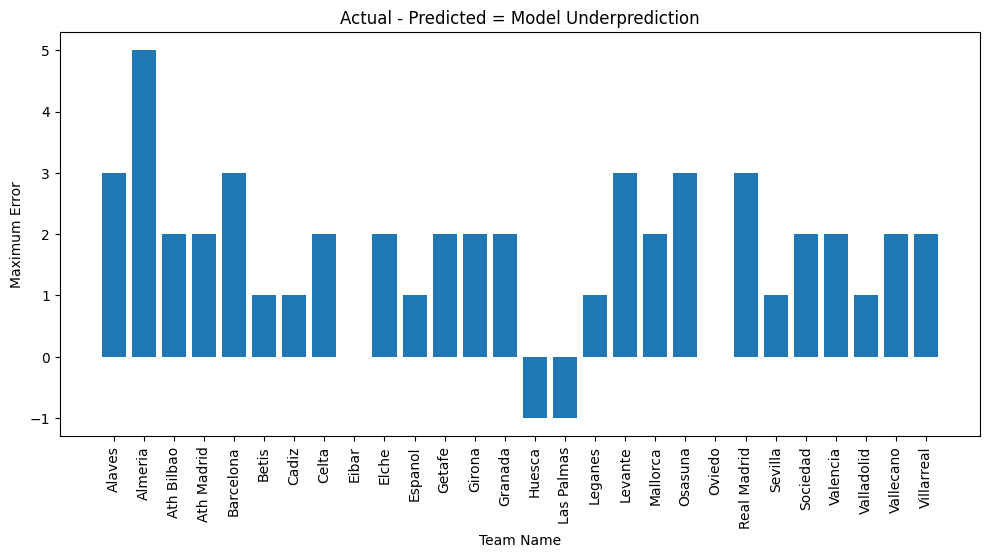

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(maxi.keys(), maxi.values())
plt.xlabel("Team Name")
plt.ylabel("Maximum Error")
plt.title("Actual - Predicted = Model Underprediction")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [22]:
#Checking patterns of teams that performed more than expected have in similar based on the plots above 3, 4 and 5

outliers = laliga[laliga["Home_Error"].isin([3, 4, 5, 6])]
outliers

,Date,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,RawPred_Home,RawPred_Away,Home_Pred,Away_Pred,Home_Error,Away_Error,Pred_home,Pred_away,Actual_Outcome,Predicted_Outcome
7,2026-03-22,Alaves,Celta,0,4,3,1.071481,1.451982,1,1,3,2,1,1,W,D
15,2024-05-25,Almeria,Cadiz,1,6,1,0.651745,1.306842,1,1,5,0,1,1,W,D
52,2026-03-15,Barcelona,Sevilla,1,5,2,2.292262,0.739121,2,1,3,1,2,1,W,W
161,2026-03-21,Levante,Oviedo,1,4,2,1.373245,1.301814,1,1,3,1,1,1,W,D
176,2026-01-17,Osasuna,Oviedo,1,3,2,0.357013,0.822424,0,1,3,1,0,1,W,L
200,2026-03-14,Real Madrid,Elche,1,4,1,1.418168,0.500986,1,1,3,0,1,1,W,D


In [23]:
outliers["IsHome"].value_counts()

IsHome
1    5
0    1
Name: count, dtype: int64

In [24]:
laliga["Match_Error"] = np.abs(laliga["Home_Error"]) + np.abs(laliga["Away_Error"])
laliga["Match_Error"].value_counts()

Match_Error
1    90
2    85
3    51
0    34
4    17
5     2
6     1
Name: count, dtype: int64

In [25]:
count = laliga["Match_Error"].isin([0, 1, 2, 3]).sum()
print(f"Total accuracy when actual total match goals - predicted total match goals is 3 or less is {round(count/len(laliga) * 100, 1)}%")

Total accuracy when actual total match goals - predicted total match goals is 3 or less is 92.9%


## There is a clear pattern that when a team is home, There is a chance it can perform more than predicted often extremely from 3 to 5 goals model underprediction. The away team in this outliers have just 3 goals model underprediction which is still manageable

# SUMMARY

## The model performs badly in 3 way scenerio (i.e home/draw/away) having 42% accuracy which isnt reliable, but performs very good in recognizing possible goals that can be scored, taking into consideration; exact goal +1, and -1 goals scenerio, with an average accuracy of 79%.

## Outliers events are 4, 5 and 6 goals underprediction. In order to put it out to production, we will focus on managing the risks associated with these errors.
## Further evaluation showed ingame red cards is a big factor for model overprediction i.e where actual goals scored is less than predicted goals